### Mijozning noroziligini (customer churn) aniqlash

Biznesda eng ko'p uchraydigan muammolardan biri. Mijozning kayfiyatini aniqlash.

Agar biznes egasi mijoz qaytmasligini, maxsulot yoki xizmatdan qayta foydanalmasligini oldindan bashorat qila olsa, mijozni ushlab qolish uchun, uning fikrini o'zgartirish uchun harakat qilishi mumkin.

Ushbu amaliyotda biz online do'kon xaridorlari ma'lumotlarini tahlil qilish orqali mijozning qolish-qolmasligini bashorat qilamiz.

In [52]:
#kutubxonalar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics



In [2]:
# dataset

df = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/Mijozlar_roziligi.csv')

df.head()

,Unnamed: 0,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,...,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,...,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,...,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,...,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,...,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,...,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
ustunlar = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/ustunlar_haqida.csv')
ustunlar

,Unnamed: 0,Data,Variable,Discerption
0,0,E Comm,CustomerID,Unique customer ID
1,1,E Comm,Churn,Churn Flag
2,2,E Comm,Tenure,Tenure of customer in organization
3,3,E Comm,PreferredLoginDevice,Preferred login device of customer
4,4,E Comm,CityTier,City tier
5,5,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
6,6,E Comm,PreferredPaymentMode,Preferred payment method of customer
7,7,E Comm,Gender,Gender of customer
8,8,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...
9,9,E Comm,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   5630 non-null   int64  
 1   CustomerID                   5630 non-null   int64  
 2   Churn                        5630 non-null   int64  
 3   Tenure                       5366 non-null   float64
 4   PreferredLoginDevice         5630 non-null   object 
 5   CityTier                     5630 non-null   int64  
 6   WarehouseToHome              5379 non-null   float64
 7   PreferredPaymentMode         5630 non-null   object 
 8   Gender                       5630 non-null   object 
 9   HourSpendOnApp               5375 non-null   float64
 10  NumberOfDeviceRegistered     5630 non-null   int64  
 11  PreferedOrderCat             5630 non-null   object 
 12  SatisfactionScore            5630 non-null   int64  
 13  MaritalStatus     

In [5]:
df.describe()

,Unnamed: 0,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,2814.500000,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,0.000000,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,1407.250000,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,2814.500000,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,4221.750000,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,5629.000000,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [6]:
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [7]:
#foizda

df['Churn'].value_counts()/len(df)*100

,count
Churn,
0,83.161634
1,16.838366


In [8]:
foizda_churn = df['Churn'].value_counts()/len(df)*100

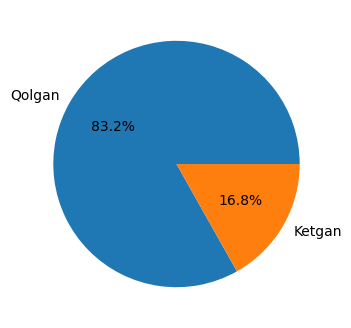

In [10]:
plt.figure(figsize=(4, 4))
plt.pie(foizda_churn, labels=['Qolgan', 'Ketgan'], autopct='%1.1f%%')
plt.show()

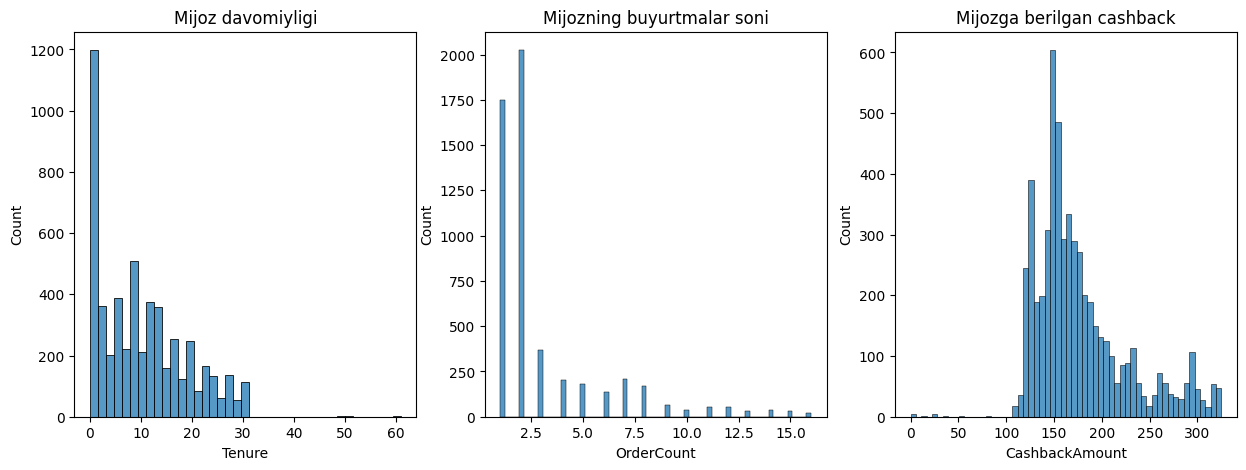

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(data=df, x='Tenure', ax=axes[0])
axes[0].set_title('Mijoz davomiyligi')

sns.histplot(data=df, x='OrderCount', ax=axes[1])
axes[1].set_title('Mijozning buyurtmalar soni')

sns.histplot(data=df, x='CashbackAmount', ax=axes[2])
axes[2].set_title('Mijozga berilgan cashback')

plt.show()

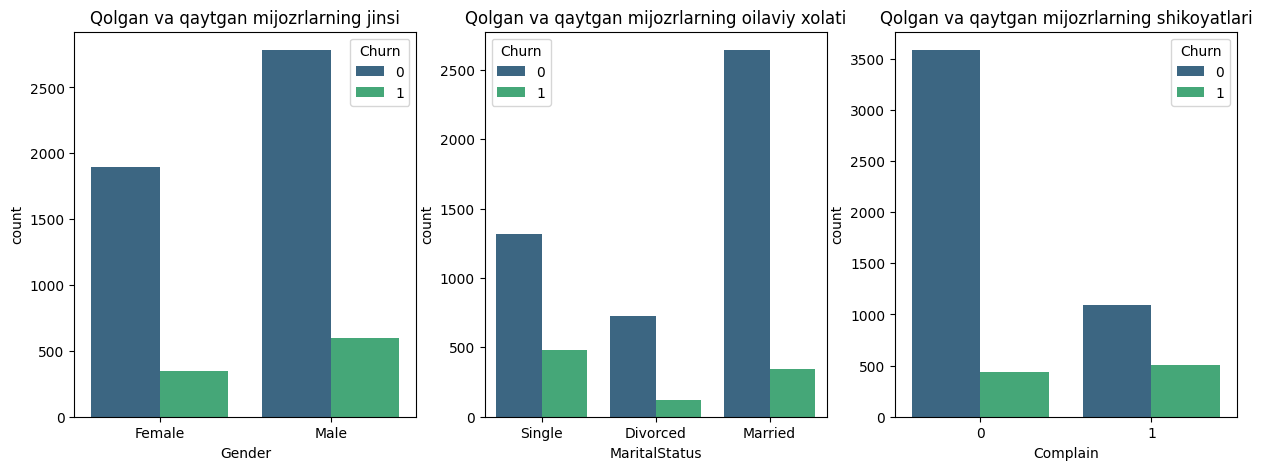

In [13]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.countplot(x='Gender', hue='Churn', palette='viridis', data=df, ax=axes[0])
axes[0].set_title("Qolgan va qaytgan mijozrlarning jinsi")

sns.countplot(x='MaritalStatus', hue='Churn', palette='viridis', data=df, ax=axes[1])
axes[1].set_title("Qolgan va qaytgan mijozrlarning oilaviy xolati")

sns.countplot(x='Complain', hue='Churn', palette='viridis', data=df, ax=axes[2])
axes[2].set_title("Qolgan va qaytgan mijozrlarning shikoyatlari")

plt.show()

In [15]:
df.corrwith(df['Churn'], numeric_only=True).abs().sort_values(ascending=False)

,0
Churn,1.000000
Tenure,0.349408
Complain,0.250188
DaySinceLastOrder,0.160757
CashbackAmount,0.154118
NumberOfDeviceRegistered,0.107939
SatisfactionScore,0.105481
CityTier,0.084703
WarehouseToHome,0.076630
NumberOfAddress,0.043931


In [16]:
#df dagi mavjud bo'lmagan qiymatlar soni
print(f"Mavjud bo'lmagan qiymatlar soni: {df.isnull().sum().sum()}")
#mavjud bo'lmagan qatorlar soni
missing_rows = df[df.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rows}")
#qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rows/len(df)*100)}%")

Mavjud bo'lmagan qiymatlar soni: 1856
Mavjud bo'lmagan qatorlar soni: 1856
Mavjud bo'lmagan qatorlar %: 33.0%


33% juda ham ko'p. Lekin biz barcha ustunlardan foydalanamizmi?

Keling korrelyasiya yuqori bo'lgan va ba'zi kategoriyali (natbnli) ustuinlarni saralab olamiz (_qaysi ustunlarni saralashni siz xal qilishingiz kerak. Biz misol berayapmiz xolos_)

In [17]:
data = df[['Churn','Tenure','Complain','DaySinceLastOrder','CashbackAmount','MaritalStatus','Gender']]

In [18]:
print(f"Mavjud bo'lmagan qiymatlar soni: {data.isnull().sum().sum()}")
#mavjud bo'lmagan qatorlar soni
missing_rows = data[data.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rows}")
#qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rows/len(data)*100)}%")

Mavjud bo'lmagan qiymatlar soni: 571
Mavjud bo'lmagan qatorlar soni: 571
Mavjud bo'lmagan qatorlar %: 10.0%


In [19]:
data = data.dropna()
data.shape

(5059, 7)

In [20]:
data['Churn'].value_counts()/len(data)*100

,count
Churn,
0,83.92963
1,16.07037


In [21]:
# Matnli ustunlarni songa o'tkazamiz
encoded = pd.get_dummies(data)
encoded.head()

,Churn,Tenure,Complain,DaySinceLastOrder,CashbackAmount,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Gender_Female,Gender_Male
0,1,4.0,1,5.0,159.93,False,False,True,True,False
3,1,0.0,0,3.0,134.07,False,False,True,False,True
4,1,0.0,0,3.0,129.60,False,False,True,False,True
5,1,0.0,1,7.0,139.19,False,False,True,True,False
8,1,13.0,1,2.0,126.83,True,False,False,False,True


In [23]:
scaler = StandardScaler()

In [24]:
x = encoded.drop('Churn', axis=1)
y = encoded['Churn']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [27]:
x_train_scaled

array([[-0.01948229, -0.63541018, -0.45605983, ...,  1.47448894,
        -0.8149003 ,  0.8149003 ],
       [ 2.4226136 ,  1.57378656, -0.45605983, ..., -0.67820108,
        -0.8149003 ,  0.8149003 ],
       [-0.36835313, -0.63541018,  1.22335247, ..., -0.67820108,
        -0.8149003 ,  0.8149003 ],
       ...,
       [-0.48464341,  1.57378656, -1.29576597, ...,  1.47448894,
        -0.8149003 ,  0.8149003 ],
       [ 0.09680799, -0.63541018, -0.17615778, ..., -0.67820108,
         1.22714398, -1.22714398],
       [-1.06609481, -0.63541018,  0.10374427, ...,  1.47448894,
         1.22714398, -1.22714398]])

ML

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       849
           1       0.65      0.33      0.43       163

    accuracy                           0.86      1012
   macro avg       0.77      0.65      0.68      1012
weighted avg       0.85      0.86      0.84      1012

Model aniqligi : 0.8636363636363636


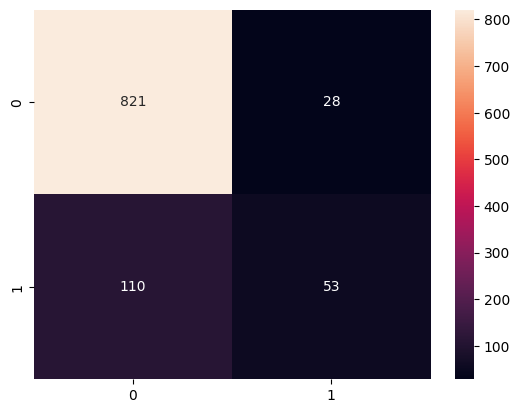

In [32]:
#Logistic Regression

LR_model = LogisticRegression()
LR_model.fit(x_train_scaled, y_train)

#Natija

y_predict = LR_model.predict(x_test_scaled)

#Xatolikni baholash

print(classification_report(y_test, y_predict))
print(f'Model aniqligi : {accuracy_score(y_test, y_predict)}')

## confusion matrix
conf_mat = confusion_matrix(y_test, y_predict)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

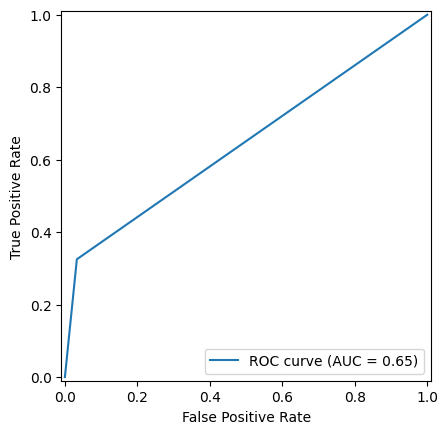

In [40]:
## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_predict)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

Support vector machines

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.84      1.00      0.91       849
           1       0.00      0.00      0.00       163

    accuracy                           0.84      1012
   macro avg       0.42      0.50      0.46      1012
weighted avg       0.70      0.84      0.77      1012

Model aniqligi: 0.8389328063241107


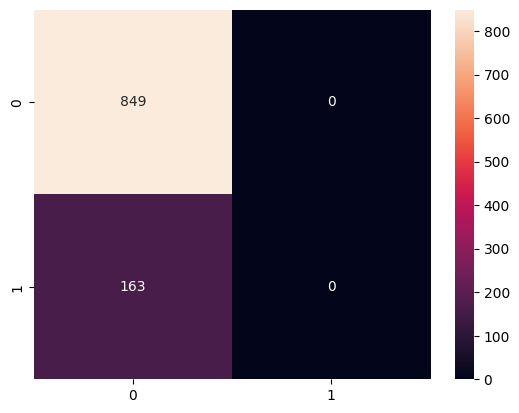

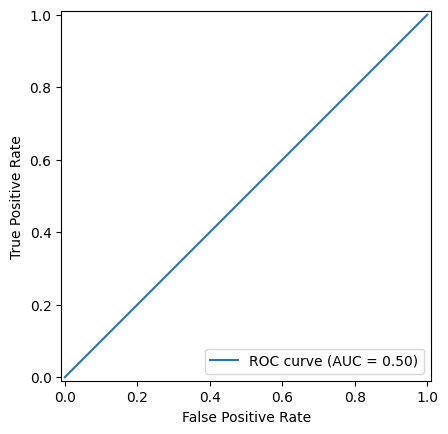

In [44]:
# Modelni yaratamiz (training)
svm_model = SVC()
svm_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = svm_model.predict(x_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

Decison Tree

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       849
           1       0.90      0.87      0.89       163

    accuracy                           0.96      1012
   macro avg       0.94      0.93      0.93      1012
weighted avg       0.96      0.96      0.96      1012

Model aniqligi: 0.9644268774703557


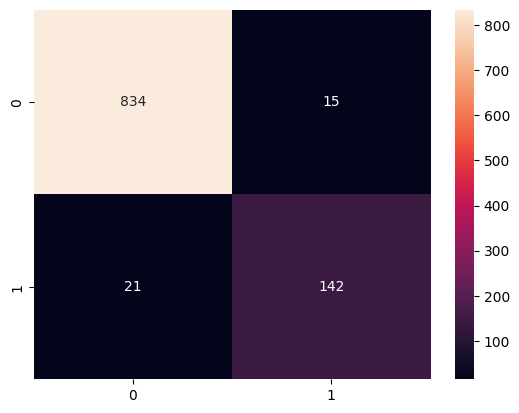

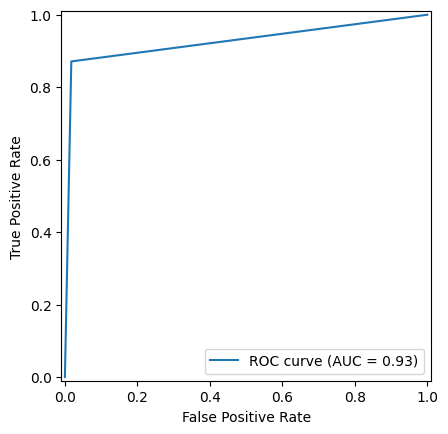

In [46]:
# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier()
tree_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(x_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

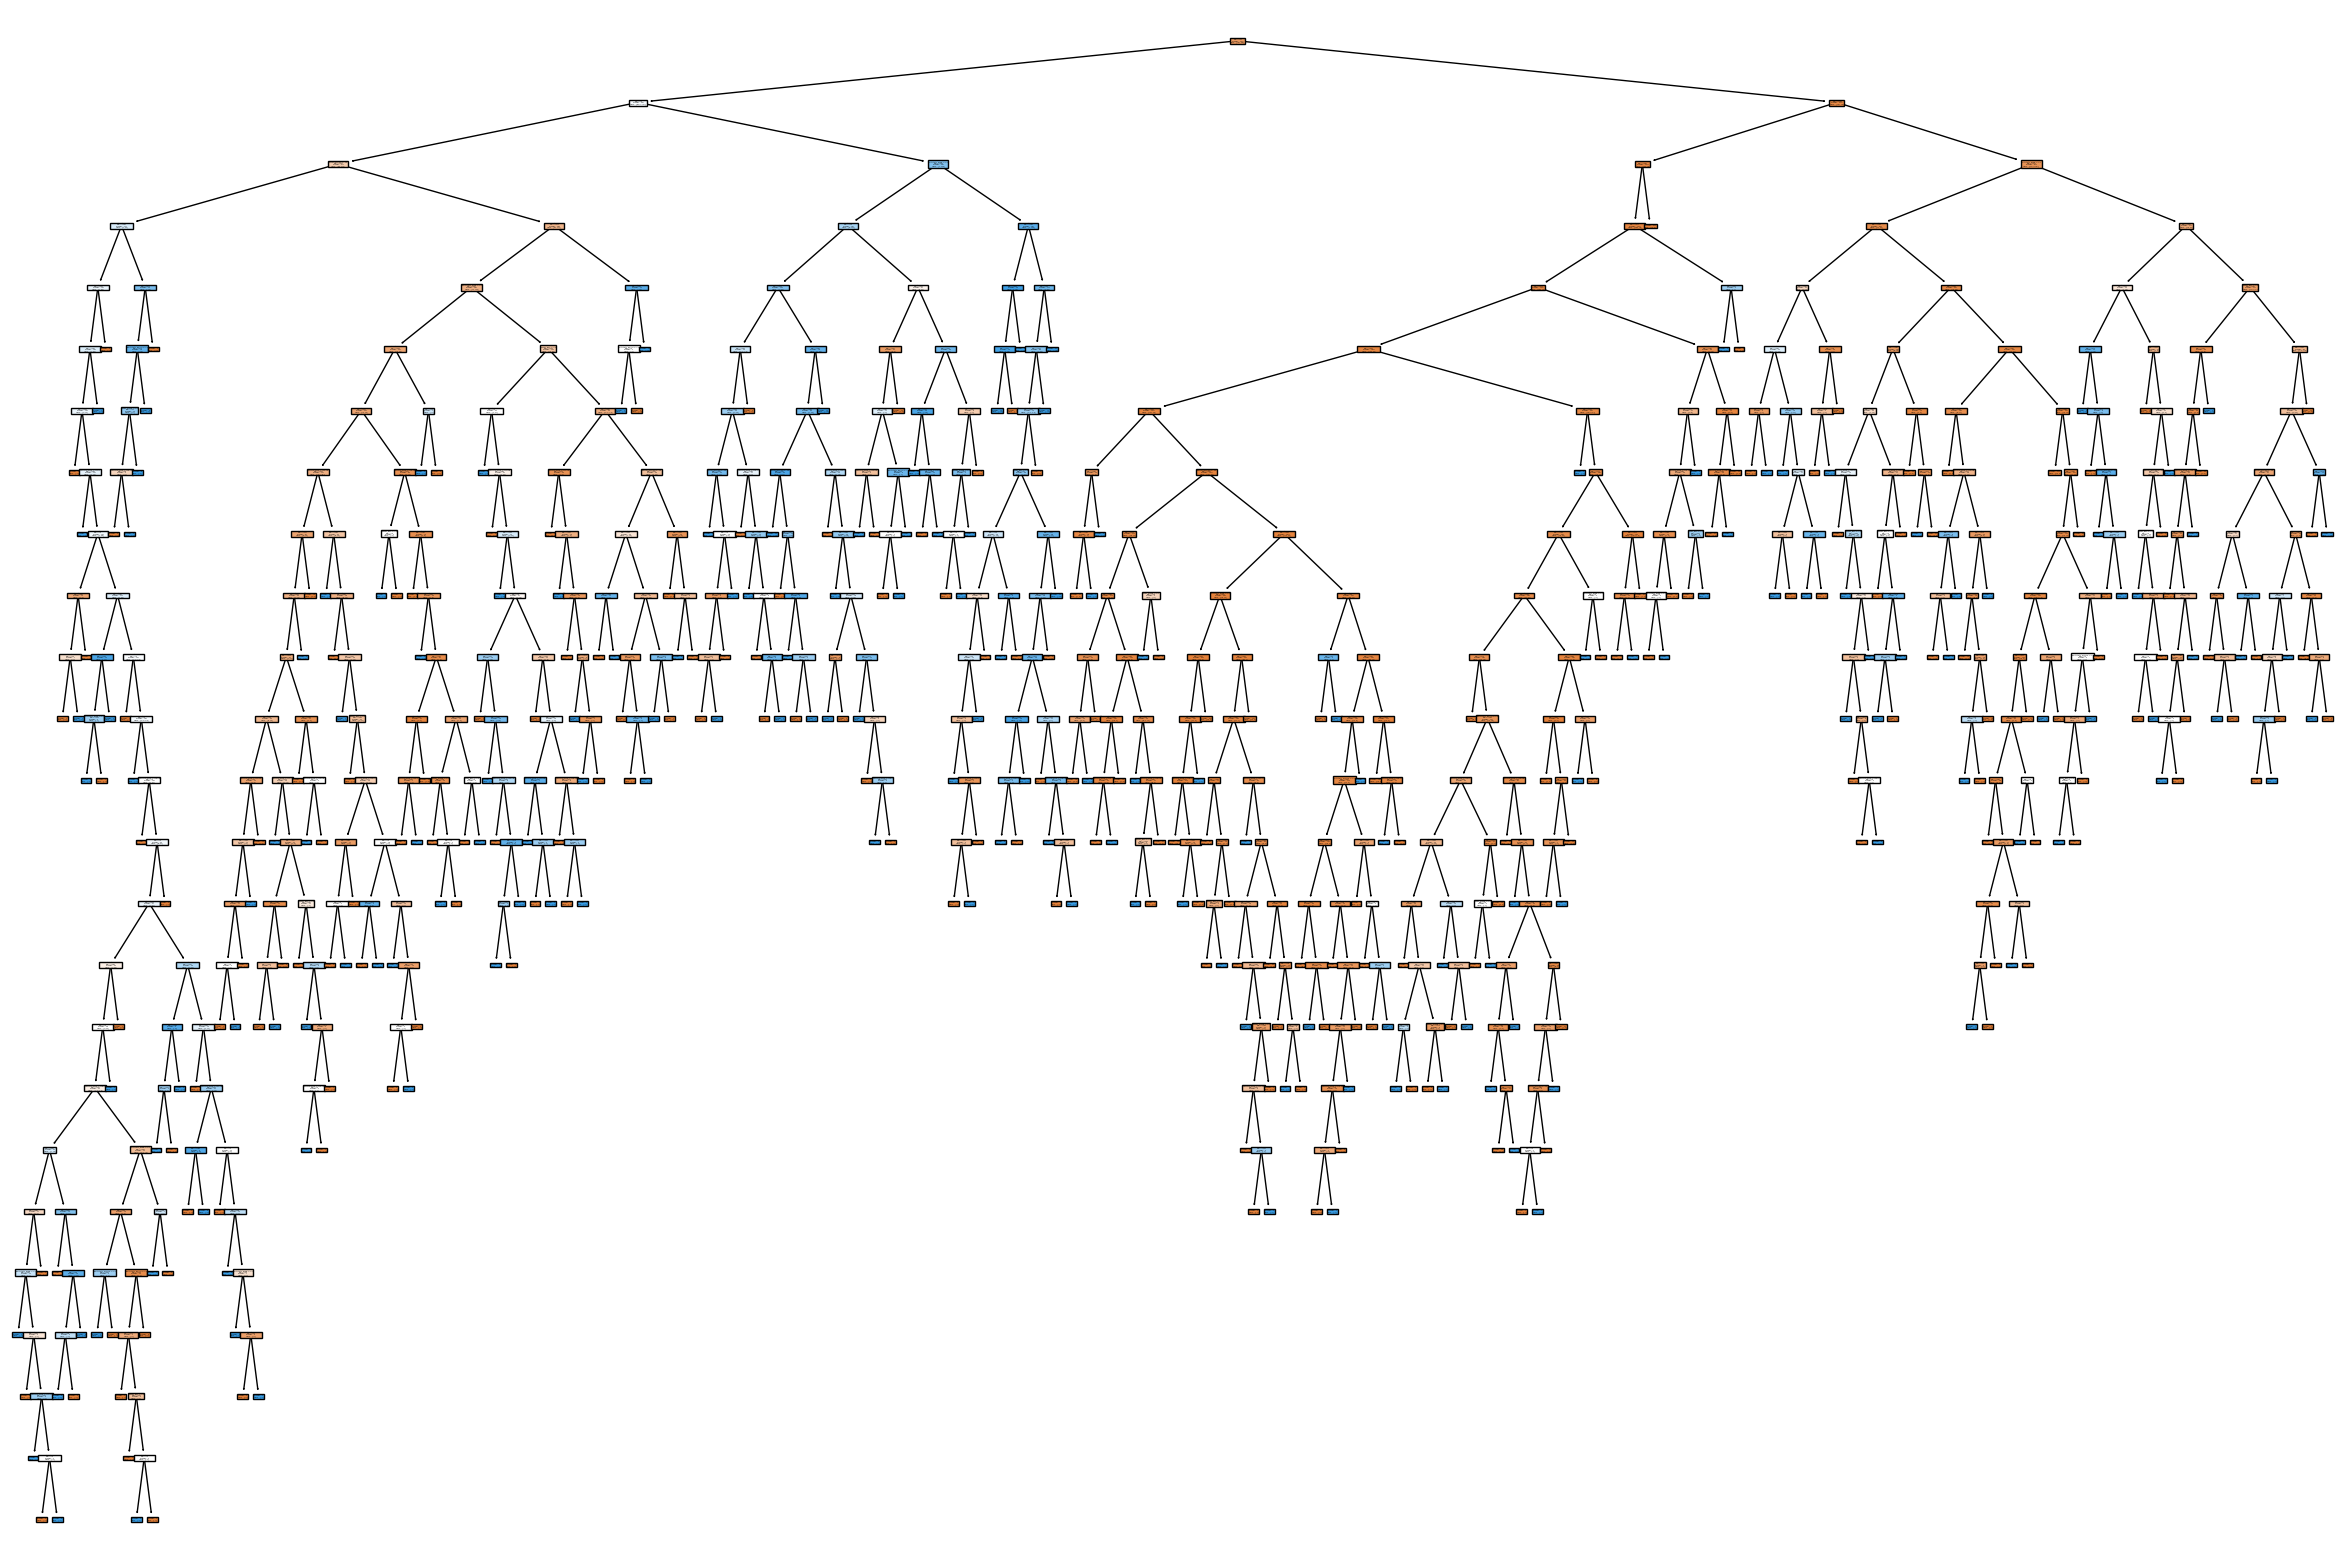

In [47]:
cols = encoded.drop('Churn', axis=1).columns

plt.figure(figsize=(30,20))
plot_tree(tree_model, feature_names=cols, filled=True)
plt.show()

Random Forest

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       849
           1       0.81      0.77      0.79       163

    accuracy                           0.93      1012
   macro avg       0.88      0.87      0.87      1012
weighted avg       0.93      0.93      0.93      1012

Model aniqligi: 0.9337944664031621


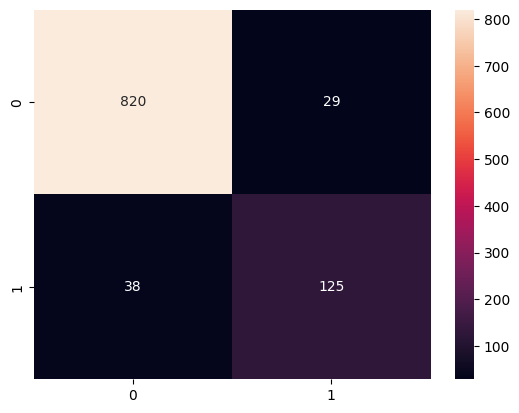

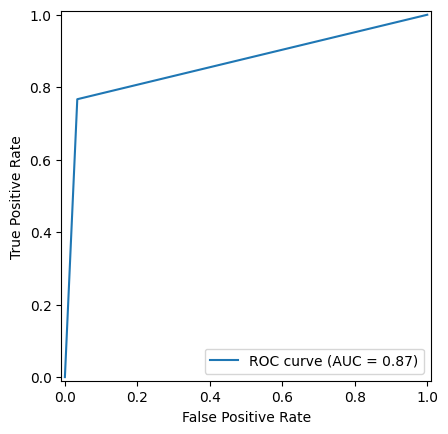

In [50]:
# Modelni yaratamiz (training)
RF_model = RandomForestClassifier(n_estimators=9)
RF_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = RF_model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

XGBoost

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       849
           1       0.86      0.74      0.79       163

    accuracy                           0.94      1012
   macro avg       0.91      0.86      0.88      1012
weighted avg       0.94      0.94      0.94      1012

Model aniqligi: 0.9387351778656127


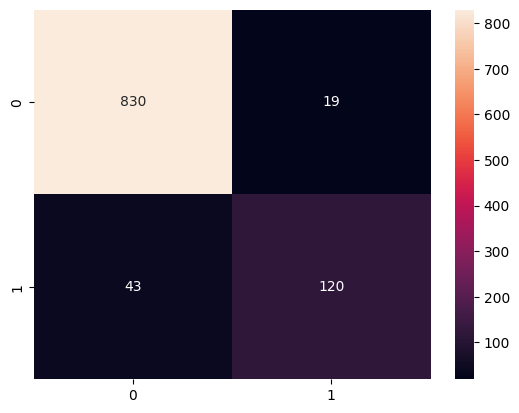

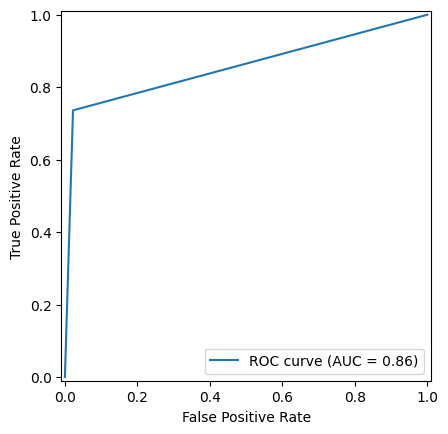

In [51]:
# Modelni yaratamiz (training)
xgb_model = XGBClassifier()
xgb_model.fit(x_train, y_train)

# Modelni baholaymiz
y_pred = xgb_model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()